
# EE344 Final Project (Rebuilt, Fixed Pipeline)

This notebook is a **new file** and does not modify your original `344Final.ipynb`.

## Pipeline order in this notebook
1. Load + validate dataset
2. Feature engineering for MediaPipe hand landmarks (including wrist-relative features)
3. Train/test split (stratified, leakage-aware setup)
4. Scale + PCA(10)
5. t-SNE visualization (before K-Means, as requested)
6. K-Means analysis for `k=2..8` (Elbow, Silhouette, FMI, cluster maps)
7. Supervised ML with labeled data (CV + holdout test)

## MediaPipe coordinate assumptions (verified)
For MediaPipe Hand Landmarker:
- `x`, `y` are normalized to `[0, 1]` by image width/height.
- `z` is depth; wrist depth is origin; smaller `z` is closer to camera.
- World landmarks are in meters with origin at hand geometric center.

References:
- https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python
- https://ai.google.dev/edge/api/mediapipe/java/com/google/mediapipe/tasks/components/containers/NormalizedLandmark


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    silhouette_score,
    fowlkes_mallows_score,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


In [2]:

# -------------------------
# 1) Load dataset
# -------------------------
DATA_PATH = Path('merged_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('/Users/y/Desktop/344MLhomework/homework/finalProject/merged_dataset.csv')

df = pd.read_csv(DATA_PATH)
print(f'Dataset path: {DATA_PATH}')
print('Shape:', df.shape)
print('Columns:', len(df.columns))

TARGET = 'direction'
assert TARGET in df.columns, f"'{TARGET}' column not found"

if 'filename' not in df.columns:
    # keep code robust if filename was removed upstream
    df['filename'] = [f'row_{i}' for i in range(len(df))]

print('\\nClass distribution:')
print(df[TARGET].value_counts())
print('\\nClass ratio (%):')
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

display(df.head())


Dataset path: merged_dataset.csv
Shape: (603, 65)
Columns: 65
\nClass distribution:
direction
Pointing_Left     332
Pointing_Right    271
Name: count, dtype: int64
\nClass ratio (%):
direction
Pointing_Left     55.06
Pointing_Right    44.94
Name: proportion, dtype: float64


,filename,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
0,IMG_9734.JPG,0.646481,0.771554,1.768660e-07,0.683290,0.711169,-0.005896,0.695399,0.647578,-0.021418,...,0.645916,0.637718,-0.093269,0.666913,0.669813,-0.083744,0.661707,0.690624,-0.071454,Pointing_Left
1,509151772433873_.pic.jpg,0.162824,0.676318,-2.872858e-07,0.299672,0.617752,-0.023162,0.377253,0.549926,-0.040260,...,0.090932,0.548127,-0.042013,0.114231,0.568613,-0.032944,0.112813,0.586741,-0.029670,Pointing_Right
2,IMG_9836.JPG,0.863716,0.546938,2.528396e-08,0.810565,0.535083,-0.036838,0.763620,0.547465,-0.063654,...,0.904119,0.720734,-0.104208,0.899656,0.659549,-0.097806,0.885778,0.621000,-0.086766,Pointing_Right
3,507961772433753_.pic.jpg,0.880592,0.755766,-5.697894e-07,0.780115,0.662776,0.026987,0.652597,0.624160,0.015813,...,0.510331,0.795934,-0.109579,0.571014,0.808296,-0.105612,0.616264,0.785701,-0.104499,Pointing_Left
4,508011772433758_.pic_thumb.jpg,0.906104,0.576748,-4.809966e-07,0.816000,0.525581,0.001459,0.707359,0.512891,-0.025827,...,0.571708,0.608426,-0.114437,0.625317,0.624875,-0.107075,0.668706,0.611069,-0.100873,Pointing_Left


In [ ]:

# -------------------------
# 2) Clean + validate schema
# -------------------------
# Define expected landmark columns
raw_xyz_cols = [f'{axis}_{i}' for i in range(21) for axis in ['x', 'y', 'z']]
missing_cols = [c for c in raw_xyz_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing expected landmark columns: {missing_cols[:10]}')

# Coerce numeric safely
for c in raw_xyz_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

before = len(df)
df = df.dropna(subset=raw_xyz_cols + [TARGET]).reset_index(drop=True)
after = len(df)
print(f'Rows before cleaning: {before}, after cleaning: {after}, dropped: {before - after}')



print('Duplicate full rows:', df.duplicated().sum())
print('Duplicate filenames:', df['filename'].duplicated().sum())


Rows before cleaning: 603, after cleaning: 603, dropped: 0
Duplicate full rows: 0
Duplicate filenames: 0


,filename,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
0,IMG_9734.JPG,0.646481,0.771554,1.768660e-07,0.683290,0.711169,-0.005896,0.695399,0.647578,-0.021418,...,0.645916,0.637718,-0.093269,0.666913,0.669813,-0.083744,0.661707,0.690624,-0.071454,Pointing_Left
1,509151772433873_.pic.jpg,0.162824,0.676318,-2.872858e-07,0.299672,0.617752,-0.023162,0.377253,0.549926,-0.040260,...,0.090932,0.548127,-0.042013,0.114231,0.568613,-0.032944,0.112813,0.586741,-0.029670,Pointing_Right
2,IMG_9836.JPG,0.863716,0.546938,2.528396e-08,0.810565,0.535083,-0.036838,0.763620,0.547465,-0.063654,...,0.904119,0.720734,-0.104208,0.899656,0.659549,-0.097806,0.885778,0.621000,-0.086766,Pointing_Right
3,507961772433753_.pic.jpg,0.880592,0.755766,-5.697894e-07,0.780115,0.662776,0.026987,0.652597,0.624160,0.015813,...,0.510331,0.795934,-0.109579,0.571014,0.808296,-0.105612,0.616264,0.785701,-0.104499,Pointing_Left
4,508011772433758_.pic_thumb.jpg,0.906104,0.576748,-4.809966e-07,0.816000,0.525581,0.001459,0.707359,0.512891,-0.025827,...,0.571708,0.608426,-0.114437,0.625317,0.624875,-0.107075,0.668706,0.611069,-0.100873,Pointing_Left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,507911772433746_.pic.jpg,0.916922,0.767400,-6.237441e-07,0.817354,0.680871,0.006743,0.682270,0.646092,-0.011235,...,0.542720,0.797904,-0.114289,0.604204,0.807187,-0.108840,0.649424,0.783589,-0.107219,Pointing_Left
599,508361772433792_.pic_thumb.jpg,0.884564,0.827789,-8.363020e-07,0.790672,0.688292,0.015853,0.624881,0.624193,-0.011579,...,0.433690,0.868387,-0.171869,0.500420,0.888301,-0.162183,0.562458,0.870898,-0.157948,Pointing_Left
600,IMG_9574.JPG,0.755279,0.815732,-4.166022e-07,0.712486,0.741942,0.032626,0.706939,0.673208,0.047009,...,0.826009,0.629372,0.016607,0.819163,0.654622,0.029969,0.811685,0.677740,0.035725,Pointing_Left
601,508651772433820_.pic_thumb.jpg,0.523516,0.905130,-6.378848e-07,0.697097,0.827079,0.036678,0.783936,0.726031,0.052879,...,0.352188,0.654765,0.008756,0.384095,0.697327,0.025996,0.391597,0.735012,0.035689,Pointing_Right


In [ ]:

# -------------------------
# 3) Feature engineering for hand landmarks
# -------------------------
def build_hand_features(frame: pd.DataFrame,
                        include_raw: bool = True,
                        include_wrist_relative: bool = True,
                        include_scale_normalized_dist: bool = True) -> pd.DataFrame:
    """
    Build robust features from MediaPipe landmarks.

    - raw features: original x_i, y_i, z_i
    - wrist-relative: (x_i-x_0, y_i-y_0, z_i-z_0)
    - scale-normalized distances to wrist (normalize by palm size distance(5,17))
    """
    parts = []

    if include_raw:
        parts.append(frame[raw_xyz_cols].copy())

    if include_wrist_relative:
        rel = {}
        for i in range(21):
            rel[f'rx_{i}'] = frame[f'x_{i}'] - frame['x_0']
            rel[f'ry_{i}'] = frame[f'y_{i}'] - frame['y_0']
            rel[f'rz_{i}'] = frame[f'z_{i}'] - frame['z_0']
        parts.append(pd.DataFrame(rel, index=frame.index))

    if include_scale_normalized_dist:
        # palm scale proxy: distance between MCP of index (5) and pinky (17)
        palm = np.sqrt(
            (frame['x_5'] - frame['x_17'])**2 +
            (frame['y_5'] - frame['y_17'])**2 +
            (frame['z_5'] - frame['z_17'])**2
        ) + 1e-8

        dst = {}
        for i in range(1, 21):
            d = np.sqrt(
                (frame[f'x_{i}'] - frame['x_0'])**2 +
                (frame[f'y_{i}'] - frame['y_0'])**2 +
                (frame[f'z_{i}'] - frame['z_0'])**2
            )
            dst[f'd_wrist_{i}_norm'] = d / palm

        # fingertip-to-wrist normalized distances (useful gesture cues)
        for i in [4, 8, 12, 16, 20]:
            d_tip = np.sqrt(
                (frame[f'x_{i}'] - frame['x_0'])**2 +
                (frame[f'y_{i}'] - frame['y_0'])**2 +
                (frame[f'z_{i}'] - frame['z_0'])**2
            )
            dst[f'd_tip_{i}_to_wrist_norm'] = d_tip / palm

        parts.append(pd.DataFrame(dst, index=frame.index))

    X = pd.concat(parts, axis=1)
    return X

X_all = build_hand_features(df)

# Label encoding (binary)
class_names = sorted(df[TARGET].unique().tolist())
class_to_id = {name: i for i, name in enumerate(class_names)}
id_to_class = {v: k for k, v in class_to_id.items()}
y_all = df[TARGET].map(class_to_id).astype(int)

print('Class map:', class_to_id)
print('Feature matrix shape:', X_all.shape)

Class map: {'Pointing_Left': 0, 'Pointing_Right': 1}
Feature matrix shape: (603, 151)


0      0
1      1
2      1
3      0
4      0
      ..
598    0
599    0
600    0
601    1
602    0
Name: direction, Length: 603, dtype: int64

In [ ]:

# -------------------------
# 4) Leakage-aware split setup
# -------------------------
# If you later add a subject_id column, switch to GroupShuffleSplit / GroupKFold.
# For now, stratified split on labels is used.

indices = np.arange(len(df))
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=y_all,
)

X_train = X_all.iloc[idx_train].reset_index(drop=True)
X_test  = X_all.iloc[idx_test].reset_index(drop=True)
y_train = y_all.iloc[idx_train].reset_index(drop=True)
y_test  = y_all.iloc[idx_test].reset_index(drop=True)


print('Train shapes:', X_train.shape, y_train.shape)
print('Test shapes :', X_test.shape, y_test.shape)
print('\\nTrain class counts:')
print(y_train.value_counts().sort_index())
print('\\nTest class counts:')
print(y_test.value_counts().sort_index())


Train shapes: (422, 151) (422,)
Test shapes : (181, 151) (181,)
\nTrain class counts:
direction
0    232
1    190
Name: count, dtype: int64
\nTest class counts:
direction
0    100
1     81
Name: count, dtype: int64


In [10]:

# -------------------------
# 5) Scale + PCA(10) for consistent unsupervised analysis
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca10 = PCA(n_components=10, random_state=SEED)
X_train_pca10 = pca10.fit_transform(X_train_scaled)
X_test_pca10 = pca10.transform(X_test_scaled)

cum_var_10 = pca10.explained_variance_ratio_.sum()
print(f'PCA(10) cumulative explained variance: {cum_var_10:.4f}')


PCA(10) cumulative explained variance: 0.9775


t-SNE on scaled engineered features (train split)


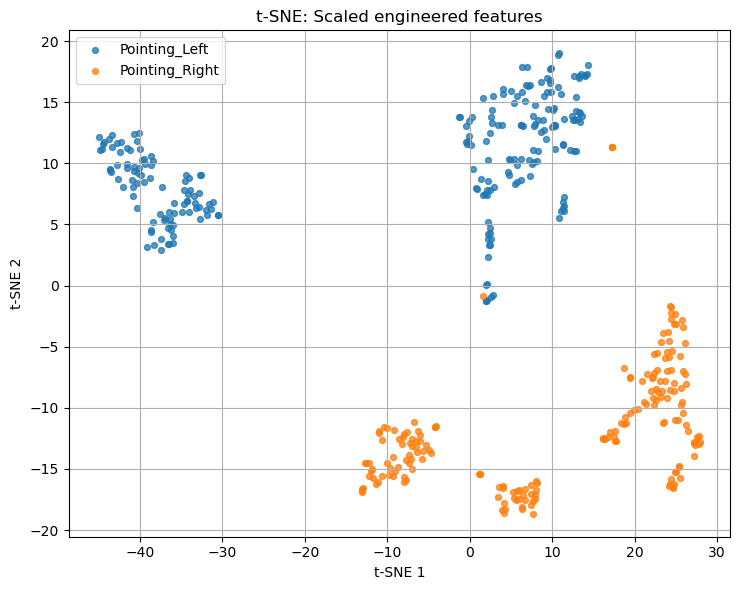

t-SNE on PCA(10) features (train split)


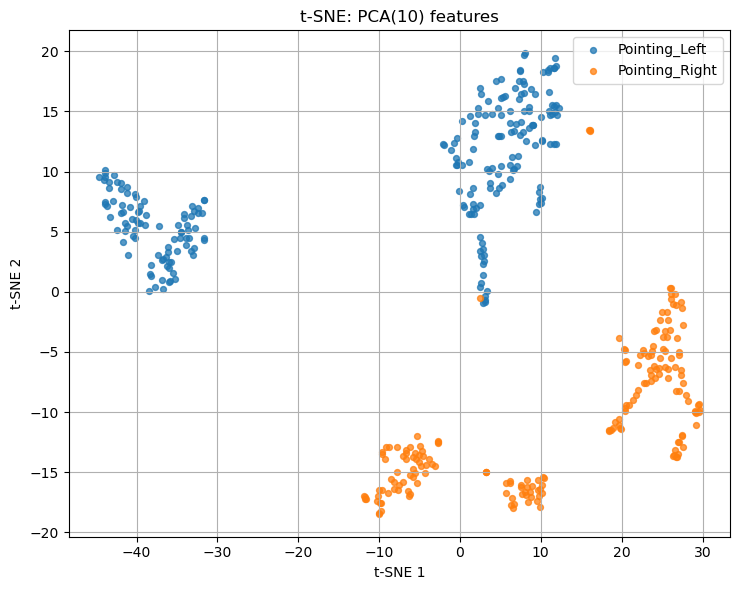

In [12]:

# -------------------------
# 6) t-SNE (before K-Means, as requested)
# -------------------------
def plot_tsne(X, y, title, seed=SEED, perplexity=30):
    # Keep perplexity valid for dataset size
    p = min(perplexity, max(5, (len(X) - 1) // 3))
    emb = TSNE(
        n_components=2,
        perplexity=p,
        init='pca',
        learning_rate='auto',
        random_state=seed,
    ).fit_transform(X)

    plt.figure(figsize=(7.5, 6))
    for cls_id in sorted(np.unique(y)):
        mask = (y == cls_id)
        plt.scatter(emb[mask, 0], emb[mask, 1], s=18, alpha=0.75, label=id_to_class[int(cls_id)])
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend()
    plt.tight_layout()
    plt.show()

print('t-SNE on scaled engineered features (train split)')
plot_tsne(X_train_scaled, y_train.values, 't-SNE: Scaled engineered features')

print('t-SNE on PCA(10) features (train split)')
plot_tsne(X_train_pca10, y_train.values, 't-SNE: PCA(10) features')


,k,inertia,silhouette,fowlkes_mallows
0,2,45517.2144,0.2686,0.5100
1,3,35111.7604,0.3320,0.5372
2,4,26268.5291,0.3907,0.6478
3,5,23629.6105,0.3882,0.6124
4,6,21180.2824,0.3566,0.5490
5,7,19157.7401,0.3710,0.5331
6,8,17567.1264,0.3830,0.5463


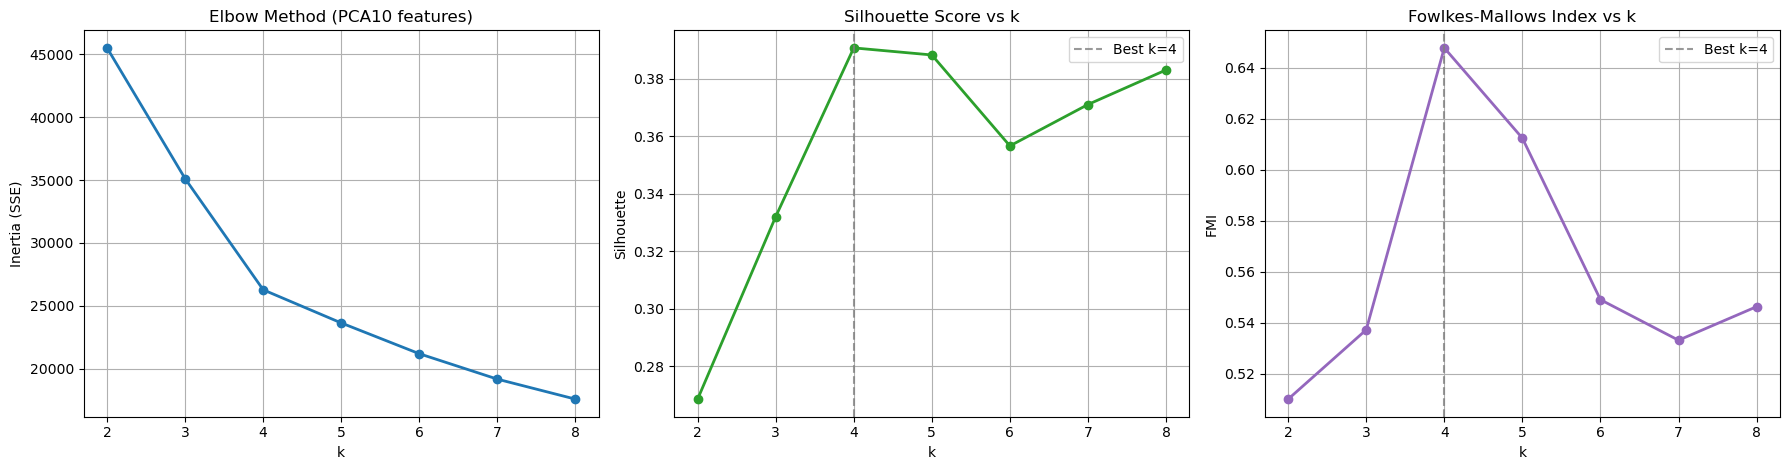

Best k by Silhouette: 4
Best k by FMI       : 4


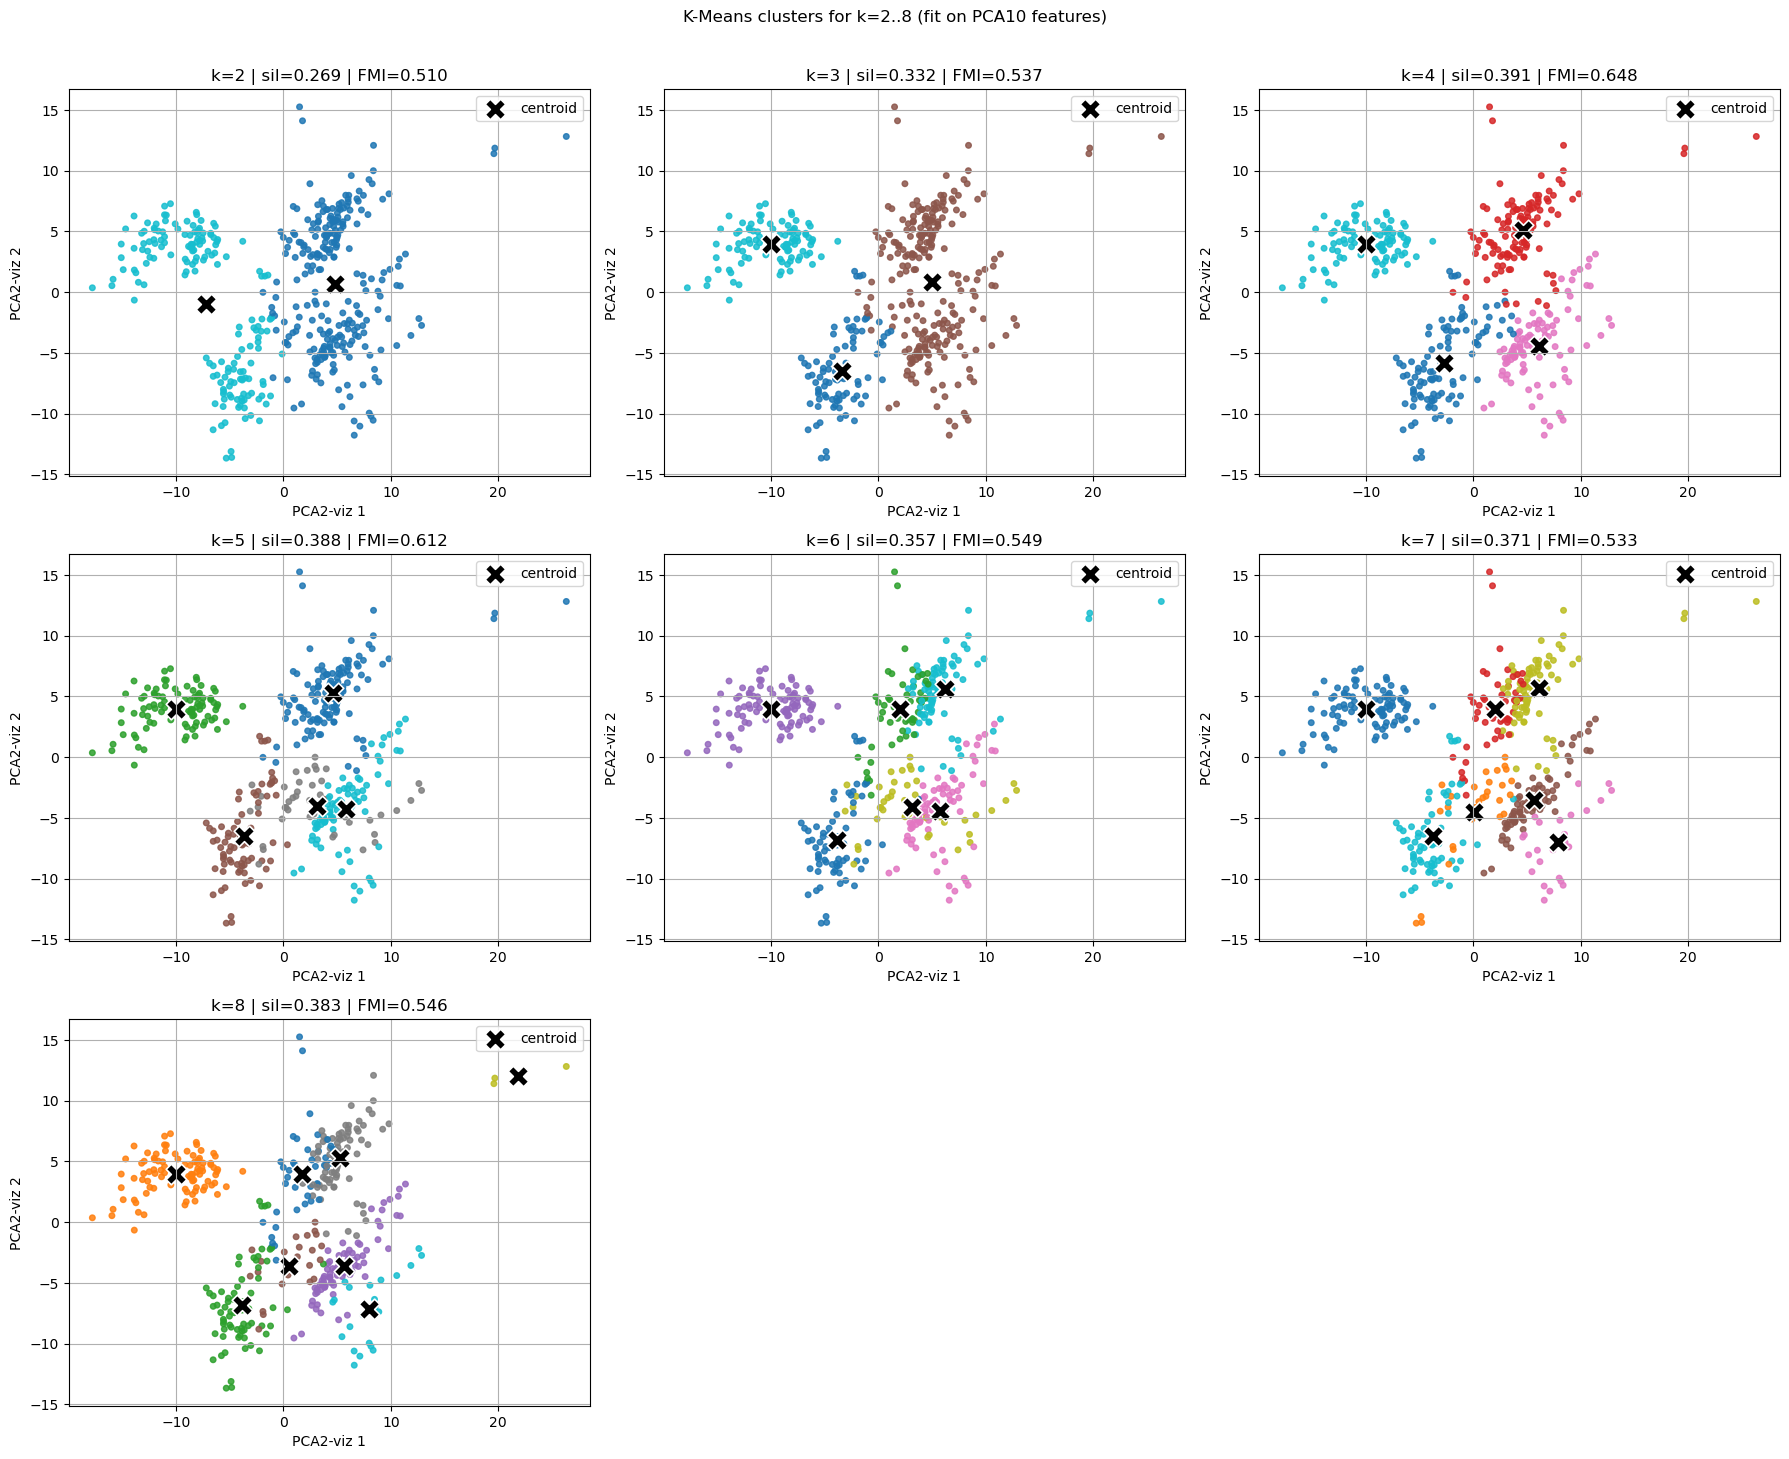

In [13]:

# -------------------------
# 7) K-Means on PCA(10): k = 2..8
# -------------------------
K_RANGE = range(2, 9)

rows = []
models_by_k = {}
labels_by_k = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_train_pca10)

    models_by_k[k] = km
    labels_by_k[k] = labels

    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_train_pca10, labels),
        'fowlkes_mallows': fowlkes_mallows_score(y_train.values, labels),
    })

km_results = pd.DataFrame(rows)
display(km_results.round(4))

best_k_sil = int(km_results.loc[km_results['silhouette'].idxmax(), 'k'])
best_k_fmi = int(km_results.loc[km_results['fowlkes_mallows'].idxmax(), 'k'])

fig, axs = plt.subplots(1, 3, figsize=(18, 4.8))

# Elbow
axs[0].plot(km_results['k'], km_results['inertia'], marker='o', linewidth=2)
axs[0].set_title('Elbow Method (PCA10 features)')
axs[0].set_xlabel('k')
axs[0].set_ylabel('Inertia (SSE)')

# Silhouette
axs[1].plot(km_results['k'], km_results['silhouette'], marker='o', linewidth=2, color='tab:green')
axs[1].axvline(best_k_sil, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_sil}')
axs[1].set_title('Silhouette Score vs k')
axs[1].set_xlabel('k')
axs[1].set_ylabel('Silhouette')
axs[1].legend(loc='best')

# FMI
axs[2].plot(km_results['k'], km_results['fowlkes_mallows'], marker='o', linewidth=2, color='tab:purple')
axs[2].axvline(best_k_fmi, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_fmi}')
axs[2].set_title('Fowlkes-Mallows Index vs k')
axs[2].set_xlabel('k')
axs[2].set_ylabel('FMI')
axs[2].legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Best k by Silhouette: {best_k_sil}')
print(f'Best k by FMI       : {best_k_fmi}')

# Cluster maps for each k (2D projection for display only)
pca2_viz = PCA(n_components=2, random_state=SEED)
X_2d = pca2_viz.fit_transform(X_train_pca10)

n_k = len(K_RANGE)
n_cols = 3
n_rows = int(np.ceil(n_k / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.8 * n_rows), squeeze=False)

for idx, k in enumerate(K_RANGE):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]

    labels = labels_by_k[k]
    km = models_by_k[k]

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=16, alpha=0.85)

    centers_2d = pca2_viz.transform(km.cluster_centers_)
    ax.scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        marker='X', s=220, c='black', edgecolors='white', linewidths=1.2, label='centroid'
    )

    sil_k = float(km_results.loc[km_results['k'] == k, 'silhouette'].values[0])
    fmi_k = float(km_results.loc[km_results['k'] == k, 'fowlkes_mallows'].values[0])

    ax.set_title(f'k={k} | sil={sil_k:.3f} | FMI={fmi_k:.3f}')
    ax.set_xlabel('PCA2-viz 1')
    ax.set_ylabel('PCA2-viz 2')
    ax.legend(loc='best')

for j in range(n_k, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis('off')

plt.suptitle('K-Means clusters for k=2..8 (fit on PCA10 features)', y=1.01)
plt.tight_layout()
plt.show()


In [14]:

# -------------------------
# 8) Supervised ML on labeled data
# -------------------------
def binary_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return acc, prec, rec, f1

models = {
    'Logistic Regression': LogisticRegression(solver='saga', max_iter=2000, random_state=SEED),
    'Linear SVM': LinearSVC(random_state=SEED),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=40, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64, 32), early_stopping=True, random_state=SEED, max_iter=300),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
fitted_models = {}

for name, clf in models.items():
    # Pipeline A: scaled features (no PCA)
    pipe_a = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf),
    ])
    cv_f1_a = cross_val_score(pipe_a, X_train, y_train, cv=cv, scoring='f1')

    pipe_a.fit(X_train, y_train)
    pred_a = pipe_a.predict(X_test)
    acc_a, prec_a, rec_a, f1_a = binary_scores(y_test, pred_a)

    rows.append({
        'Model': f'{name} (Scaled)',
        'CV F1 Mean': cv_f1_a.mean(),
        'CV F1 Std': cv_f1_a.std(),
        'Test Acc': acc_a,
        'Test Prec': prec_a,
        'Test Rec': rec_a,
        'Test F1': f1_a,
    })
    fitted_models[f'{name} (Scaled)'] = pipe_a

    # Pipeline B: scaled + PCA(10)
    pipe_b = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=10, random_state=SEED)),
        ('clf', clf),
    ])
    cv_f1_b = cross_val_score(pipe_b, X_train, y_train, cv=cv, scoring='f1')

    pipe_b.fit(X_train, y_train)
    pred_b = pipe_b.predict(X_test)
    acc_b, prec_b, rec_b, f1_b = binary_scores(y_test, pred_b)

    rows.append({
        'Model': f'{name} (Scaled+PCA10)',
        'CV F1 Mean': cv_f1_b.mean(),
        'CV F1 Std': cv_f1_b.std(),
        'Test Acc': acc_b,
        'Test Prec': prec_b,
        'Test Rec': rec_b,
        'Test F1': f1_b,
    })
    fitted_models[f'{name} (Scaled+PCA10)'] = pipe_b

results = pd.DataFrame(rows).sort_values('Test F1', ascending=False).reset_index(drop=True)

for col in ['CV F1 Mean','CV F1 Std','Test Acc','Test Prec','Test Rec','Test F1']:
    results[col] = results[col].round(4)

print('=== Supervised ML Results (sorted by Test F1) ===')
display(results)


=== Supervised ML Results (sorted by Test F1) ===


,Model,CV F1 Mean,CV F1 Std,Test Acc,Test Prec,Test Rec,Test F1
0,Random Forest (Scaled+PCA10),0.9873,0.0194,1.0000,1.0000,1.0000,1.0000
1,Logistic Regression (Scaled),0.9922,0.0103,0.9945,1.0000,0.9877,0.9938
2,Logistic Regression (Scaled+PCA10),0.9896,0.0096,0.9945,1.0000,0.9877,0.9938
3,Linear SVM (Scaled),0.9947,0.0064,0.9945,1.0000,0.9877,0.9938
4,Linear SVM (Scaled+PCA10),0.9871,0.0115,0.9945,1.0000,0.9877,0.9938
5,KNN (k=7) (Scaled),0.9947,0.0064,0.9945,1.0000,0.9877,0.9938
6,KNN (k=7) (Scaled+PCA10),0.9947,0.0064,0.9945,1.0000,0.9877,0.9938
7,Random Forest (Scaled),0.9897,0.0096,0.9890,0.9877,0.9877,0.9877
8,Decision Tree (Scaled+PCA10),0.9407,0.0235,0.9724,0.9750,0.9630,0.9689
9,Decision Tree (Scaled),0.9895,0.0053,0.9724,0.9872,0.9506,0.9686


Best model: Random Forest (Scaled+PCA10)
\nClassification report:
                precision    recall  f1-score   support

 Pointing_Left     1.0000    1.0000    1.0000       100
Pointing_Right     1.0000    1.0000    1.0000        81

      accuracy                         1.0000       181
     macro avg     1.0000    1.0000    1.0000       181
  weighted avg     1.0000    1.0000    1.0000       181



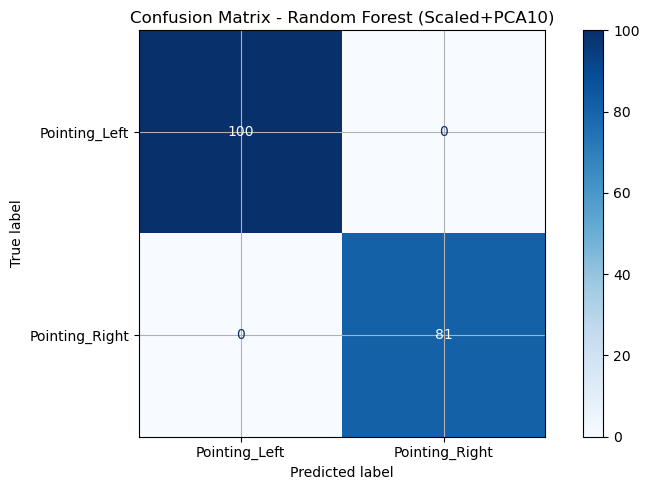

In [15]:

# -------------------------
# 9) Best model diagnostics
# -------------------------
best_model_name = results.iloc[0]['Model']
best_model = fitted_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print('Best model:', best_model_name)
print('\\nClassification report:')
print(classification_report(
    y_test,
    y_pred_best,
    target_names=[id_to_class[i] for i in sorted(id_to_class.keys())],
    digits=4,
))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[id_to_class[i] for i in sorted(id_to_class.keys())],
)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()



## Notes for presentation

- This pipeline prevents common leakage mistakes by:
  - splitting with label stratification before fitting scalers/PCA,
  - fitting scalers/PCA inside each model pipeline during CV,
  - keeping `filename` metadata out of feature columns.
- t-SNE is for visualization only (not for model training).
- K-Means is unsupervised analysis; supervised metrics should drive final model choice.


I0000 00:00:1773082255.949688 5107483 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1
W0000 00:00:1773082255.954901 5107485 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773082255.959441 5107485 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


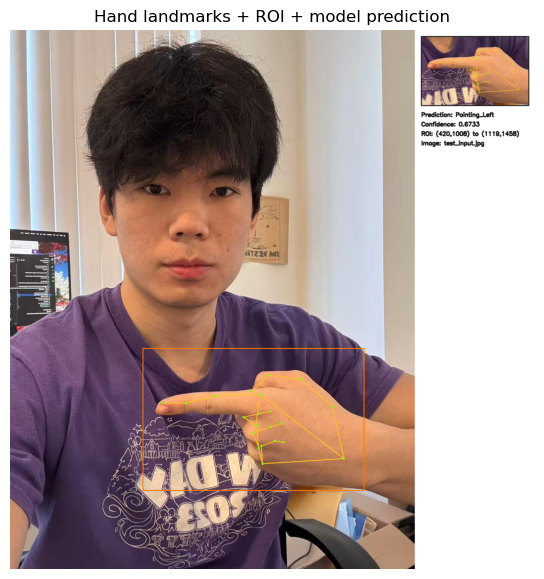

Predicted class: Pointing_Left
Confidence     : 0.6733
MediaPipe hand : Left (0.9732)


In [12]:
# 10) Single-image inference with MediaPipe + trained model
# Run all previous cells first (so build_hand_features, X_train, id_to_class, best_model exist)

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ---------- User inputs ----------
INPUT_IMAGE = Path('/Users/y/Desktop/344MLhomework/homework/finalProject/test_input.jpg')  # <-- change this
LANDMARKER_TASK = Path('/Users/y/Desktop/344MLhomework/homework/finalProject/model/hand_landmarker.task')
NUM_HANDS = 1
PADDING = 0.05  # bbox padding in normalized coords

# ---------- Checks ----------
required_vars = ['build_hand_features', 'X_train', 'id_to_class', 'best_model']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables {missing}. Run notebook cells from top before this inference cell.')

if not INPUT_IMAGE.exists():
    raise FileNotFoundError(f'Input image not found: {INPUT_IMAGE}')
if not LANDMARKER_TASK.exists():
    raise FileNotFoundError(f'Landmarker task not found: {LANDMARKER_TASK}')

# ---------- Load image ----------
bgr = cv2.imread(str(INPUT_IMAGE))
if bgr is None:
    raise ValueError(f'Could not read image: {INPUT_IMAGE}')

h, w = bgr.shape[:2]
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# ---------- Run MediaPipe Hand Landmarker ----------
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(LANDMARKER_TASK)),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=NUM_HANDS,
)

with HandLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

if not result.hand_landmarks:
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb)
    plt.title('No hand detected')
    plt.axis('off')
    plt.show()
    raise RuntimeError('No hand landmarks detected in the input image.')

# Pick first detected hand
hand_landmarks = result.hand_landmarks[0]
handedness_label = 'Unknown'
handedness_score = None
if result.handedness and len(result.handedness) > 0 and len(result.handedness[0]) > 0:
    handedness_label = result.handedness[0][0].category_name
    handedness_score = float(result.handedness[0][0].score)

# ---------- Convert landmarks to one-row dataframe ----------
row = {}
for i, lm in enumerate(hand_landmarks):
    row[f'x_{i}'] = float(lm.x)
    row[f'y_{i}'] = float(lm.y)
    row[f'z_{i}'] = float(lm.z)
row_df = pd.DataFrame([row])

# Build features exactly like training pipeline
X_one = build_hand_features(row_df)
X_one = X_one.reindex(columns=X_train.columns, fill_value=0.0)

# ---------- Predict ----------
y_pred_id = int(best_model.predict(X_one)[0])
y_pred_label = id_to_class.get(y_pred_id, str(y_pred_id))

# Optional confidence estimate
confidence_text = 'N/A'
if hasattr(best_model, 'predict_proba'):
    p = best_model.predict_proba(X_one)[0]
    confidence_text = f'{float(np.max(p)):.4f}'
elif hasattr(best_model, 'decision_function'):
    d = best_model.decision_function(X_one)
    if np.ndim(d) == 1:
        # convert margin magnitude to pseudo-confidence in [0,1]
        conf = 1.0 / (1.0 + np.exp(-abs(float(d[0]))))
    else:
        conf = float(np.max(d))
    confidence_text = f'{conf:.4f} (margin-based)'

# ---------- Draw landmarks + ROI ----------
annotated = bgr.copy()

# Hand connections (fallback list if API shape differs)
try:
    hand_connections = list(mp.solutions.hands.HAND_CONNECTIONS)
except Exception:
    hand_connections = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (5,9),(9,10),(10,11),(11,12),
        (9,13),(13,14),(14,15),(15,16),
        (13,17),(17,18),(18,19),(19,20),
        (0,17)
    ]

# Draw connections
for conn in hand_connections:
    s, e = int(conn[0]), int(conn[1])
    x1, y1 = int(hand_landmarks[s].x * w), int(hand_landmarks[s].y * h)
    x2, y2 = int(hand_landmarks[e].x * w), int(hand_landmarks[e].y * h)
    cv2.line(annotated, (x1, y1), (x2, y2), (40, 190, 255), 2)

# Draw landmark points
for i, lm in enumerate(hand_landmarks):
    x, y = int(lm.x * w), int(lm.y * h)
    cv2.circle(annotated, (x, y), 4, (0, 255, 120), -1)

# Compute bounding box (ROI)
xs = np.array([lm.x for lm in hand_landmarks])
ys = np.array([lm.y for lm in hand_landmarks])

x_min = int(max(0, (xs.min() - PADDING) * w))
y_min = int(max(0, (ys.min() - PADDING) * h))
x_max = int(min(w - 1, (xs.max() + PADDING) * w))
y_max = int(min(h - 1, (ys.max() + PADDING) * h))

cv2.rectangle(annotated, (x_min, y_min), (x_max, y_max), (0, 120, 255), 2)

roi = annotated[y_min:y_max+1, x_min:x_max+1]
if roi.size == 0:
    roi = np.ones((120, 120, 3), dtype=np.uint8) * 255

# ---------- Create side panel ----------
panel_w = 380
canvas = np.ones((h, w + panel_w, 3), dtype=np.uint8) * 255
canvas[:, :w] = annotated

# Place ROI preview in side panel
max_roi_w = panel_w - 40
max_roi_h = max(120, int(h * 0.45))
scale = min(max_roi_w / roi.shape[1], max_roi_h / roi.shape[0])
new_w = max(1, int(roi.shape[1] * scale))
new_h = max(1, int(roi.shape[0] * scale))
roi_resized = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_AREA)

x0 = w + 20
y0 = 20
canvas[y0:y0+new_h, x0:x0+new_w] = roi_resized
cv2.rectangle(canvas, (x0, y0), (x0+new_w, y0+new_h), (30, 30, 30), 2)

# Text summary on side panel
text_lines = [
    f'Prediction: {y_pred_label}',
    f'Confidence: {confidence_text}',
    f'ROI: ({x_min},{y_min}) to ({x_max},{y_max})',
    f'Image: {INPUT_IMAGE.name}'
]

ty = y0 + new_h + 35
for line in text_lines:
    cv2.putText(canvas, line, (w + 20, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (20, 20, 20), 2, cv2.LINE_AA)
    ty += 30

# ---------- Display ----------
plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('Hand landmarks + ROI + model prediction')
plt.axis('off')
plt.show()

print('Predicted class:', y_pred_label)
print('Confidence     :', confidence_text)
print('MediaPipe hand :', handedness_label, f'({handedness_score:.4f})' if handedness_score is not None else '(N/A)')
